# Customer Churn Prediction
## Business Machine Learning Project

### Objective
The goal of this project is to predict which customers are likely to leave a telecom company.

### Why this project matters
Customer churn is one of the most important business problems in subscription-based industries. If a company can identify customers at high risk of leaving, it can take preventive actions such as targeted offers, loyalty rewards, or service improvements.

### Project goals
In this notebook, we will:

- Explore customer churn patterns
- Clean and preprocess the data
- Build multiple machine learning models
- Evaluate model performance
- Identify the most important drivers of churn
- Translate results into business recommendations

# Import Libraries

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

In [11]:
import os

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/metrics", exist_ok=True)

# Visual Style

In [12]:
# Professional visualization style
sns.set_theme(style="whitegrid", context="notebook")

PRIMARY = "#1f3b5c"      # deep navy
SECONDARY = "#4f6d7a"    # muted blue-grey
ACCENT = "#d9a441"       # warm gold
SUCCESS = "#2a9d8f"      # teal
DANGER = "#c44e52"       # muted red
LIGHT = "#e9ecef"        # light grey
DARK = "#222222"         # near black

## 1. Load Dataset

We begin by loading the Telco Customer Churn dataset and inspecting its structure.

In [13]:
df = pd.read_csv("../data/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
print("Shape of dataset:", df.shape)
print("\nColumn types:\n")
print(df.dtypes)

Shape of dataset: (7043, 21)

Column types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 2. Data Cleaning

The dataset does not contain standard missing values in most columns, but `TotalCharges` is stored as text and contains blank strings for some customers.

We will:
- Convert `TotalCharges` to numeric
- Remove rows with missing values
- Drop `customerID` because it does not help prediction

# Clean TotalCharges and Drop ID

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df = df.drop("customerID", axis=1)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis

In this section, we explore churn patterns and customer characteristics.

We focus on:
- Churn distribution
- Contract type
- Monthly charges
- Tenure
- Correlation structure

# Churn Distribution

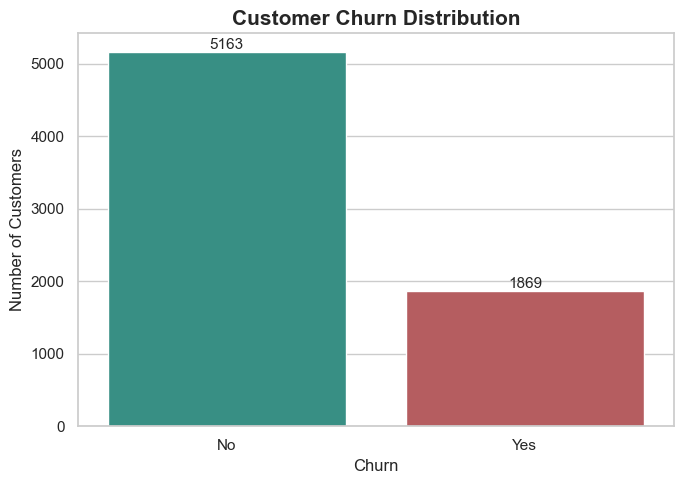

In [17]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="Churn", palette=[SUCCESS, DANGER])

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)

plt.title("Customer Churn Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../outputs/figures/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Churn Distribution Explanation

### Insight
This chart shows the balance between customers who stayed and customers who churned.

A churn dataset is usually imbalanced, which means fewer customers leave than stay. This is important because imbalance can affect machine learning model performance.

# Churn by Contract Type

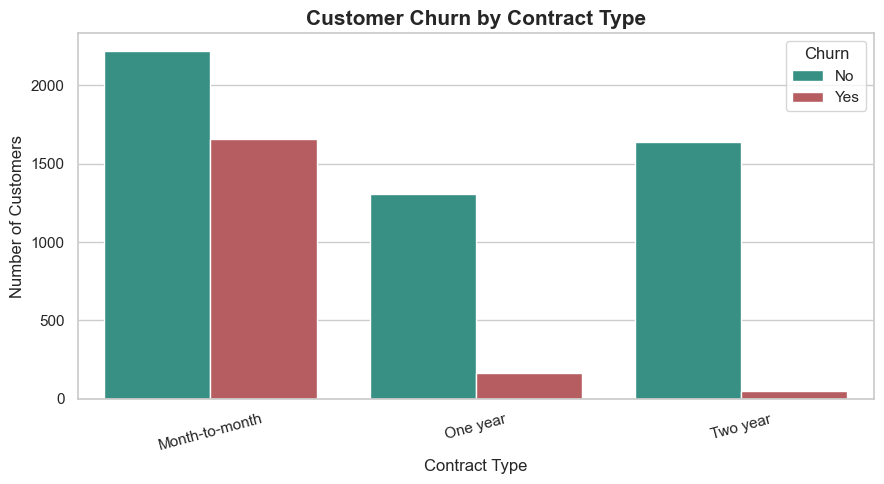

In [18]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x="Contract", hue="Churn", palette=[SUCCESS, DANGER])

plt.title("Customer Churn by Contract Type", fontsize=15, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("../outputs/figures/churn_vs_contract.png", dpi=300, bbox_inches="tight")
plt.show()

# Contract Insight

### Insight
Customers on month-to-month contracts tend to churn much more than those on one-year or two-year contracts.

This suggests that long-term contracts improve retention and reduce customer loss.

# Monthly Charges vs Churn

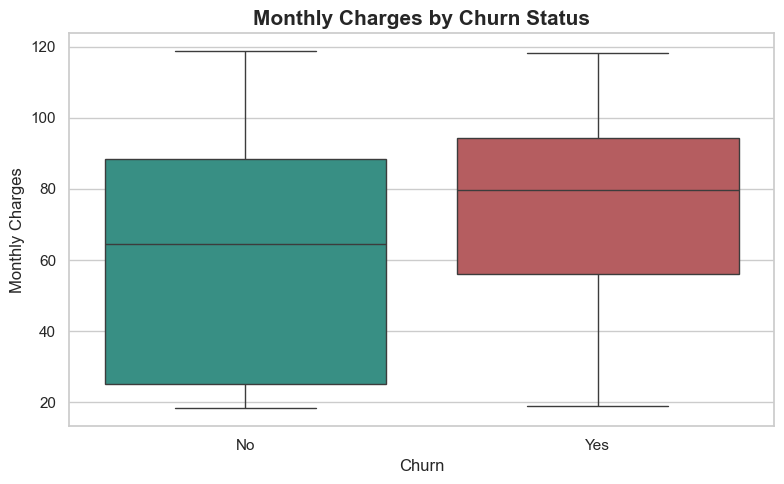

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=[SUCCESS, DANGER])

plt.title("Monthly Charges by Churn Status", fontsize=15, fontweight="bold")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_charges_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
Customers who churn often have higher monthly charges than customers who stay.

This may indicate price sensitivity or dissatisfaction with value for money.

# Tenure Distribution by Churn

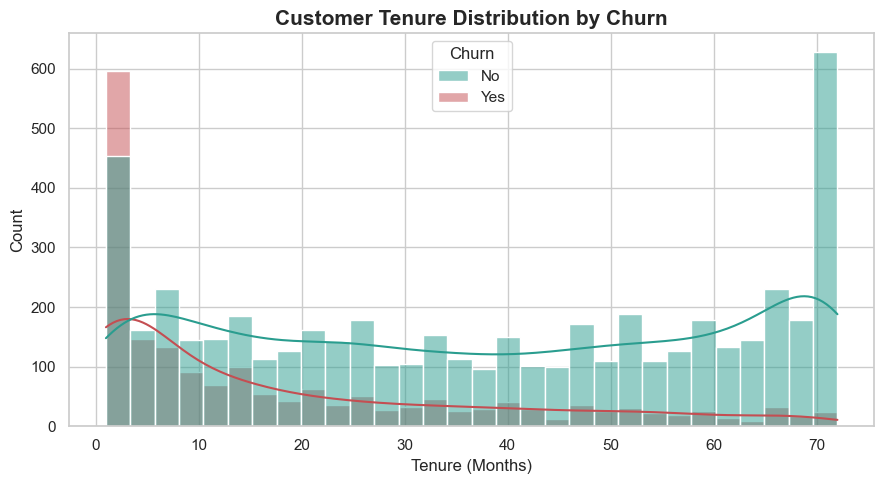

In [20]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    palette=[SUCCESS, DANGER],
    alpha=0.5
)

plt.title("Customer Tenure Distribution by Churn", fontsize=15, fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/tenure_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

# Tenure Insight

### Insight
Customers with shorter tenure are more likely to churn, while long-tenure customers are much more likely to stay.

This suggests that early customer retention is a critical business priority.

# Churn Rate by Payment Method

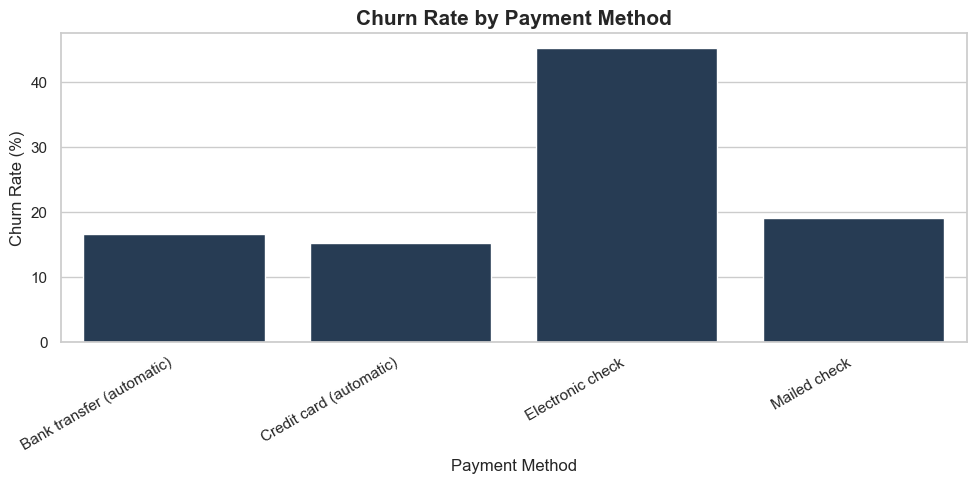

In [21]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn = payment_churn.reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=payment_churn, x="PaymentMethod", y="Yes", color=PRIMARY)

plt.title("Churn Rate by Payment Method", fontsize=15, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/churn_rate_payment_method.png", dpi=300, bbox_inches="tight")
plt.show()

# Payment Method Insight

### Insight
Different payment methods are associated with different churn rates.

This may reflect customer convenience, trust, or billing experience.

# Correlation Heatmap

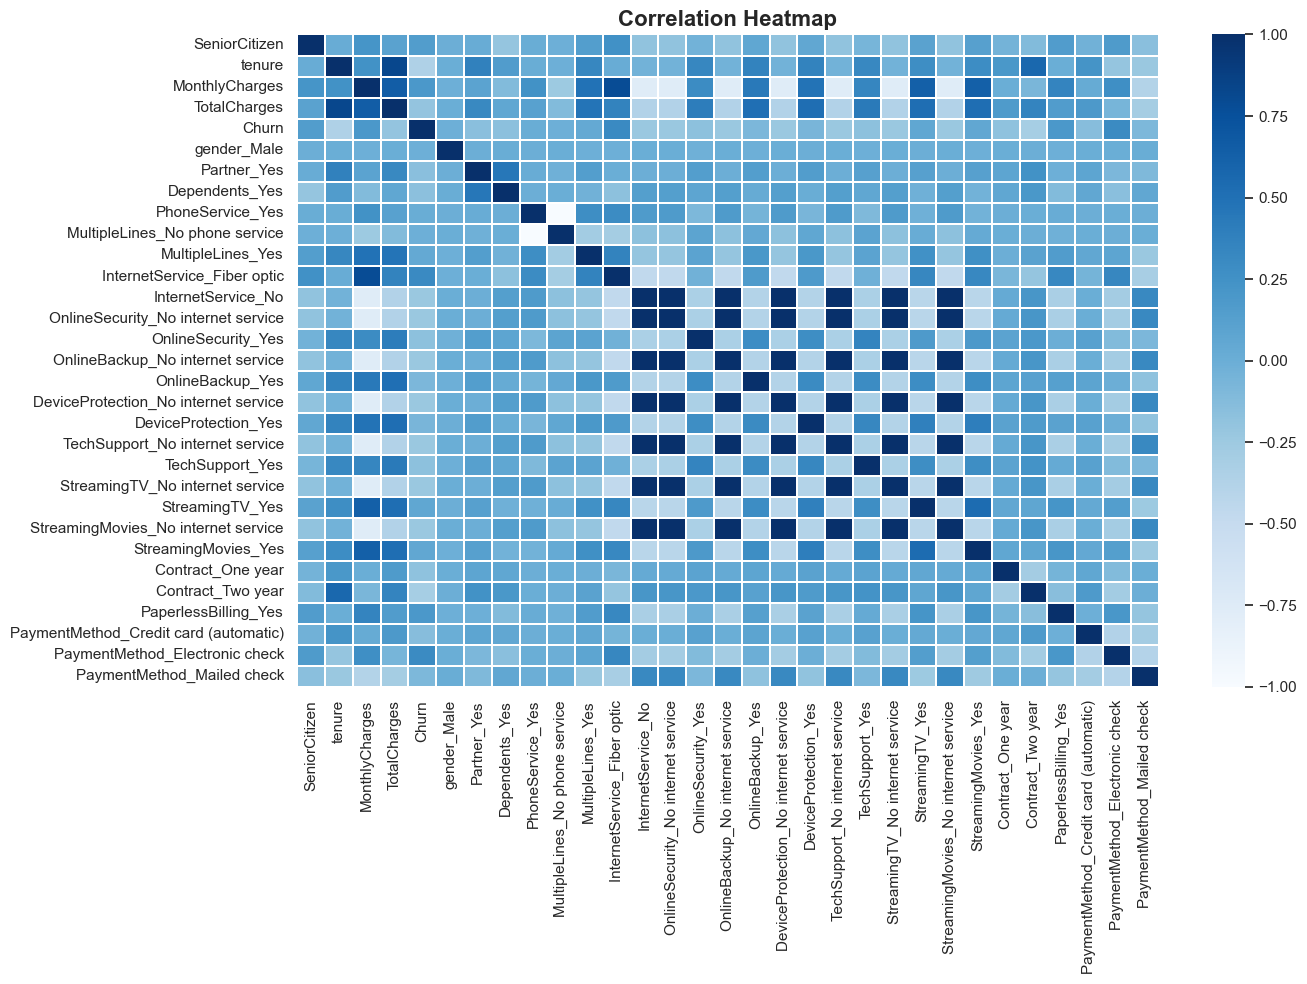

In [22]:
df_corr = df.copy()
df_corr["Churn"] = df_corr["Churn"].map({"Yes": 1, "No": 0})
df_corr_encoded = pd.get_dummies(df_corr, drop_first=True)

plt.figure(figsize=(14, 10))
corr = df_corr_encoded.corr()

sns.heatmap(
    corr,
    cmap="Blues",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Preprocessing

## 4. Data Preprocessing

Before modelling, we need to:
- Convert the target variable into numeric form
- Encode categorical features
- Split the data into training and testing sets
- Scale features for models that are sensitive to feature magnitude

# Create Modelling DataFrame

In [23]:
df_model = df.copy()

df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})
df_model = pd.get_dummies(df_model, drop_first=True)

print("Modeling dataset shape:", df_model.shape)
df_model.head()

Modeling dataset shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


# Features and Target

In [24]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7032, 30)
Target shape: (7032,)


# Train Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


# Scale Features

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

## 5. Model Training

We will train and compare three models:

1. Logistic Regression  
2. Random Forest  
3. Gradient Boosting  

This helps us compare a linear baseline with more advanced tree-based methods.

# Train Models

In [27]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
gb = GradientBoostingClassifier(random_state=42)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# Predictions

In [28]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_gb = gb.predict_proba(X_test)[:, 1]

# Model Evaluation Function

In [29]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

# Compare Model Performance

In [30]:
results = pd.DataFrame([
    evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression"),
    evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest"),
    evaluate_model(y_test, y_pred_gb, y_prob_gb, "Gradient Boosting")
])

results = results.sort_values(by="ROC-AUC", ascending=False)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.840662
1,Random Forest,0.767591,0.546535,0.737968,0.627986,0.835864
0,Logistic Regression,0.726368,0.490939,0.796791,0.607543,0.834977


# Model Evaluation Explanation

## 6. Model Evaluation

We evaluate models using:

- **Accuracy**: overall correctness
- **Precision**: how many predicted churners were actually churners
- **Recall**: how many true churners the model identified
- **F1 Score**: balance between precision and recall
- **ROC-AUC**: ability to distinguish churners from non-churners

For churn prediction, recall is especially important because missing a churn-risk customer can mean lost revenue.

# Save Metrics

In [31]:
results.to_csv("../outputs/metrics/model_scores.csv", index=False)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.840662
1,Random Forest,0.767591,0.546535,0.737968,0.627986,0.835864
0,Logistic Regression,0.726368,0.490939,0.796791,0.607543,0.834977


# Metrics Visualization

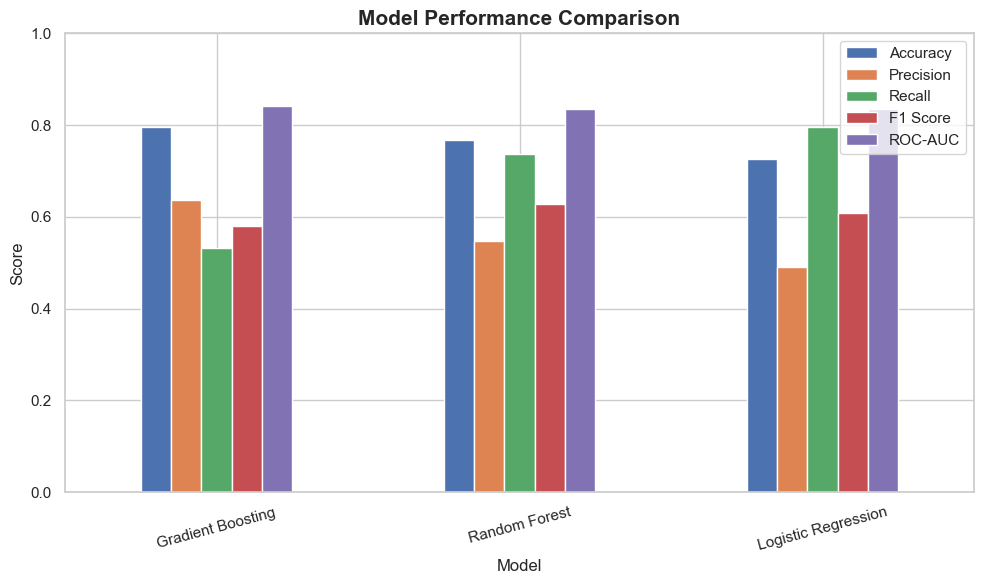

In [32]:
results_plot = results.set_index("Model")

results_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../outputs/figures/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Best Model Selection

In [33]:
best_model_name = results.iloc[0]["Model"]
print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Gradient Boosting


## 7. Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified.

It helps us understand:
- True positives: churners correctly identified
- False positives: non-churners incorrectly flagged
- True negatives: non-churners correctly identified
- False negatives: churners missed by the model

# Confusion Matrix for Random Forest

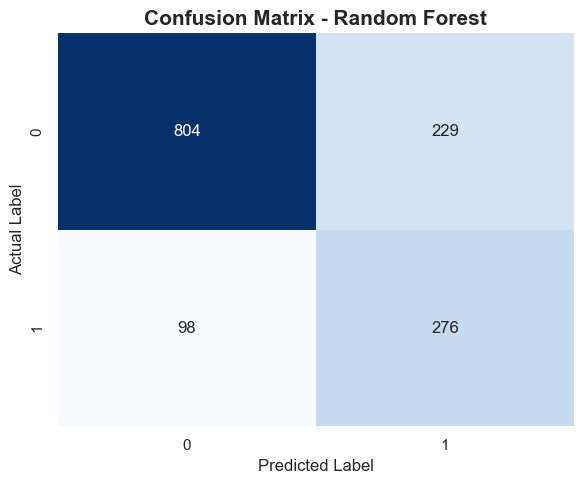

In [34]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Confusion Matrix - Random Forest", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Classification Report

In [35]:
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



## 8. ROC Curve

The ROC curve shows how well a model separates churners from non-churners across different thresholds.

A higher AUC means better discrimination ability.

# ROC Curve Comparison

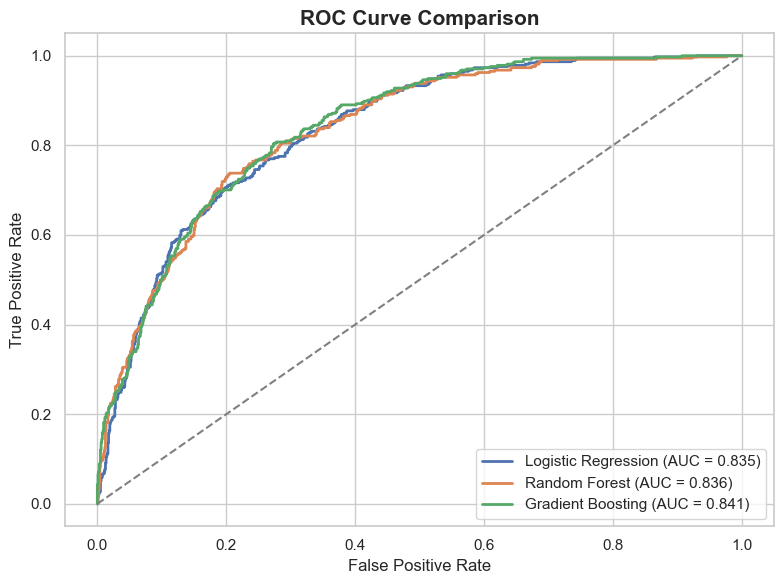

In [36]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})", linewidth=2)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison", fontsize=15, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Feature Importance

Feature importance helps explain which variables most strongly influence customer churn.

This is one of the most valuable sections because it converts machine learning output into business insight.

# Random Forest Feature Importance

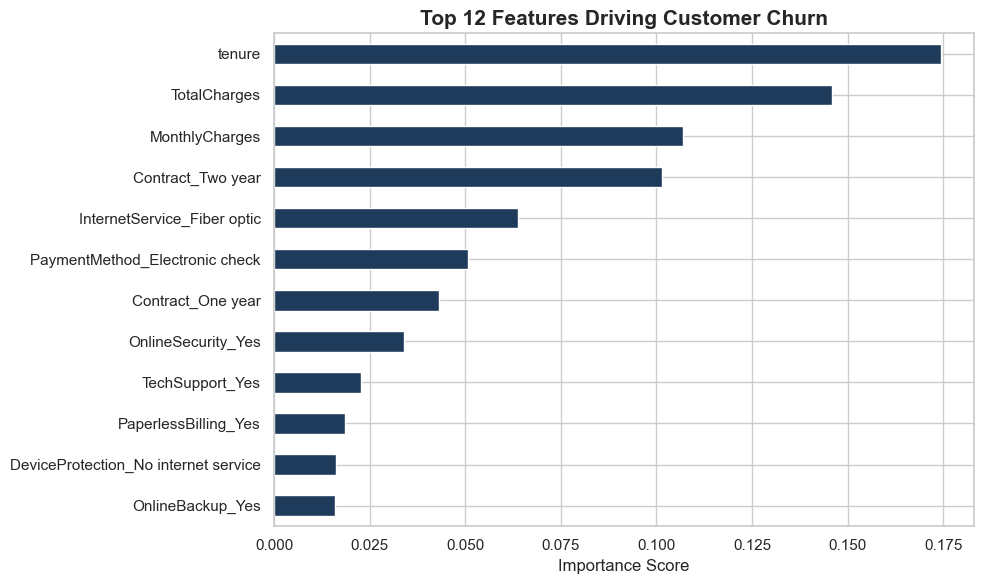

In [37]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(12).sort_values()

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh", color=PRIMARY)

plt.title("Top 12 Features Driving Customer Churn", fontsize=15, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Top Features Table

In [38]:
feature_importance.head(12).to_frame("Importance")

,Importance
tenure,0.174356
TotalCharges,0.145987
MonthlyCharges,0.106957
Contract_Two year,0.101401
InternetService_Fiber optic,0.063765
PaymentMethod_Electronic check,0.050735
Contract_One year,0.043169
OnlineSecurity_Yes,0.033874
TechSupport_Yes,0.022723
PaperlessBilling_Yes,0.018462


# Business Insights

## 10. Business Insights

Based on the analysis and model outputs, the key churn drivers are:

- Customers on **month-to-month contracts** are much more likely to churn
- Customers with **high monthly charges** show greater churn risk
- Customers with **short tenure** are more likely to leave early
- Service-related features such as **tech support** and **online security** may influence retention

### Business Recommendations

A telecom company could reduce churn by:

1. Encouraging customers to move from month-to-month to longer-term contracts  
2. Offering loyalty discounts to high-risk customers  
3. Improving support services for newer customers  
4. Creating targeted retention campaigns for customers with high monthly charges

# Conclusion

## 11. Conclusion

This project demonstrates a full business machine learning workflow:

- Data cleaning and preprocessing
- Exploratory analysis and storytelling
- Multiple model training and comparison
- Business-oriented evaluation
- Feature importance analysis
- Actionable recommendations

This makes the project useful not only as a technical exercise, but also as a real business case study in customer retention analytics.

# Best Model Summary

In [39]:
print("Final Model Comparison:\n")
print(results)

print("\nTop 10 Most Important Features:\n")
print(feature_importance.head(10))

Final Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2    Gradient Boosting  0.795309   0.637821  0.532086  0.580175  0.840662
1        Random Forest  0.767591   0.546535  0.737968  0.627986  0.835864
0  Logistic Regression  0.726368   0.490939  0.796791  0.607543  0.834977

Top 10 Most Important Features:

tenure                            0.174356
TotalCharges                      0.145987
MonthlyCharges                    0.106957
Contract_Two year                 0.101401
InternetService_Fiber optic       0.063765
PaymentMethod_Electronic check    0.050735
Contract_One year                 0.043169
OnlineSecurity_Yes                0.033874
TechSupport_Yes                   0.022723
PaperlessBilling_Yes              0.018462
dtype: float64
